Load and Prepare Stock Price Data

In this step, we load our stock price dataset (OHLCV data) into a Pandas DataFrame.

The dataset must contain at least the following columns:

- **Open** — Opening price  
- **High** — Highest price of the day  
- **Low** — Lowest price  
- **Close** — Closing price  
- **Volume** — Number of shares traded  
- **Adj Close** — Adjusted closing price (optional but useful)

After loading:

1. Convert the `Date` column to datetime format  
2. Sort the data by date  
3. Set the date column as the index  
4. Inspect the first few rows  

This prepares clean data for technical indicator calculations (SMA, EMA, RSI, MACD) in later steps.


In [24]:
import pandas as pd
from pathlib import Path

# Path to your stock price folder
data_path = Path("../Data/yfinance_data/Data")

# List all CSVs inside the folder
csv_files = list(data_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV files found in Data/yfinance_data/Data/. Please add stock price CSVs.")

print(f"Found {len(csv_files)} stock files.")

# Dictionary that will hold all processed DataFrames
stock_data = {}

# Loop through each CSV
for file in csv_files:
    try:
        print(f"\nLoading: {file.name}")

        # Load CSV
        df = pd.read_csv(file)

        # Clean column names
        df.columns = df.columns.str.strip().str.lower()

        # Convert Date column → datetime
        if "date" not in df.columns:
            raise KeyError(f"'Date' column missing in {file.name}")

        df["date"] = pd.to_datetime(df["date"], errors="coerce")

        # Drop rows where date failed to convert
        df = df.dropna(subset=["date"])

        # Sort by date
        df = df.sort_values("date")

        # Set Date as index
        df = df.set_index("date")

        # Save processed df into dictionary using ticker name (filename)
        stock_name = file.stem.upper()    # e.g. AAPL.csv → "AAPL"
        stock_data[stock_name] = df

        # Preview sample rows
        print(df.head())

    except Exception as e:
        print(f"❌ Error processing {file.name}: {e}")


Found 6 stock files.

Loading: AAPL.csv
               close      high       low      open      volume
date                                                          
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800

Loading: AMZN.csv
            close    high     low    open     volume
date                                                
2009-01-02  2.718  2.7265  2.5535  2.5675  145928000
2009-01-05  2.703  2.7870  2.6515  2.7865  190196000
2009-01-06  2.868  2.9110  2.6875  2.7275  221602000
2009-01-07  2.810  2.8475  2.7675  2.8145  158854000
2009-01-08  2.858  2.8660  2.7290  2.7495  131558000

Loading: GOOG.csv
               close      high       low      open     volume
date                                            

## Validate Required OHLCV Columns

Before proceeding to technical analysis, we must verify that the dataset contains:

- open  
- high  
- low  
- close  
- volume  



In [25]:
required_cols = ["open", "high", "low", "close", "volume"]

# Loop through each processed stock DataFrame
for stock_name, df in stock_data.items():
    print(f"\nChecking required columns for: {stock_name}")

    for col in required_cols:
        if col not in df.columns:
            print(f"WARNING: {stock_name} is missing column: {col.upper()}")
        else:
            print(f"{stock_name}: Column found → {col.upper()}")



Checking required columns for: AAPL
AAPL: Column found → OPEN
AAPL: Column found → HIGH
AAPL: Column found → LOW
AAPL: Column found → CLOSE
AAPL: Column found → VOLUME

Checking required columns for: AMZN
AMZN: Column found → OPEN
AMZN: Column found → HIGH
AMZN: Column found → LOW
AMZN: Column found → CLOSE
AMZN: Column found → VOLUME

Checking required columns for: GOOG
GOOG: Column found → OPEN
GOOG: Column found → HIGH
GOOG: Column found → LOW
GOOG: Column found → CLOSE
GOOG: Column found → VOLUME

Checking required columns for: META
META: Column found → OPEN
META: Column found → HIGH
META: Column found → LOW
META: Column found → CLOSE
META: Column found → VOLUME

Checking required columns for: MSFT
MSFT: Column found → OPEN
MSFT: Column found → HIGH
MSFT: Column found → LOW
MSFT: Column found → CLOSE
MSFT: Column found → VOLUME

Checking required columns for: NVDA
NVDA: Column found → OPEN
NVDA: Column found → HIGH
NVDA: Column found → LOW
NVDA: Column found → CLOSE
NVDA: Column f

## Create Daily Returns Column

Daily returns help us compute:

- volatility  
- annualized return  
- Sharpe ratio  
- correlation with news sentiment (later)

Formula used:

\[
\text{Daily Return} = \frac{\text{Adj Close}_t - \text{Adj Close}_{t-1}}{\text{Adj Close}_{t-1}}
\]

If `Adj Close` does not exist, we fallback to `Close`.


In [26]:
# Compute daily returns for each stock DataFrame
for stock_name, df in stock_data.items():
    print(f"\nComputing daily returns for: {stock_name}")

    if "adj close" in df.columns:
        df["daily_return"] = df["adj close"].pct_change()
        print(f"{stock_name}: using ADJ CLOSE")
    elif "close" in df.columns:
        df["daily_return"] = df["close"].pct_change()
        print(f"{stock_name}: using CLOSE")
    else:
        print(f"WARNING: {stock_name} has no 'adj close' or 'close' column!")

    # Preview first few rows
    print(df.head())




Computing daily returns for: AAPL
AAPL: using CLOSE
               close      high       low      open      volume  daily_return
date                                                                        
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200           NaN
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400      0.042204
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400     -0.016494
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800     -0.021609
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800      0.018570

Computing daily returns for: AMZN
AMZN: using CLOSE
            close    high     low    open     volume  daily_return
date                                                              
2009-01-02  2.718  2.7265  2.5535  2.5675  145928000           NaN
2009-01-05  2.703  2.7870  2.6515  2.7865  190196000     -0.005519
2009-01-06  2.868  2.9110  2.6875  2.7275  221602000      0.061043
2009-01-07  2.810  2

## Summary of Prepared Data

Now we inspect:

- DataFrame shape  
- Date range  
- Basic statistics  
- Missing values  

This ensures the dataset is clean before computing indicators.


In [27]:
# Loop through each processed stock DataFrame
for stock_name, df in stock_data.items():
    print(f"\n===== Summary for {stock_name} =====")

    # Shape of the DataFrame
    print("Shape:", df.shape)

    # Date range
    print("Date Range:", df.index.min(), "→", df.index.max())

    # Missing values
    print("\nMissing Values:")
    print(df.isna().sum())

    # Descriptive statistics
    print("\nDescriptive Statistics:")
    print(df.describe())



===== Summary for AAPL =====
Shape: (3774, 6)
Date Range: 2009-01-02 00:00:00 → 2023-12-29 00:00:00

Missing Values:
close           0
high            0
low             0
open            0
volume          0
daily_return    1
dtype: int64

Descriptive Statistics:
             close         high          low         open        volume  \
count  3774.000000  3774.000000  3774.000000  3774.000000  3.774000e+03   
mean     53.841169    54.383801    53.247465    53.801628  2.640640e+08   
std      55.064042    55.627235    54.440128    55.009182  2.345629e+08   
min       2.345299     2.459265     2.345299     2.380989  2.404830e+07   
25%      15.050355    15.183043    14.901886    15.007580  9.581845e+07   
50%      26.975808    27.168844    26.836844    27.010205  1.667348e+08   
75%      74.664204    75.252383    73.553555    74.127927  3.777410e+08   
max     196.256592   197.752460   195.156944   196.167437  1.880998e+09   

       daily_return  
count   3773.000000  
mean       0.001

## Compute Technical Indicators

Compute:
- SMA(20), EMA(20)
- RSI(14)
- MACD (12,26,9) and MACD signal/hist if available

Attempt to use TA-Lib (if installed). If not available, we fall back to `pandas_ta`.  
Indicators are saved to `results_task2/indicators_<TICKER>.csv`.


In [28]:
from pathlib import Path
import numpy as np

use_talib = False
try:
    import talib
    use_talib = True
    print("Using TA-Lib for indicators.")
except Exception as e:
    print("TA-Lib not available:", e)

# attempt pandas_ta
try:
    import pandas_ta as pta
    print("pandas_ta loaded (will use if TA-Lib not available).")
except Exception as e:
    pta = None
    print("pandas_ta not available:", e)

# Loop through each stock DataFrame
for stock_name, df in stock_data.items():
    print(f"\nComputing indicators for: {stock_name}")
    df_ind = df.copy()

    if use_talib:
        import talib as ta
        close = df_ind['close'].astype(float).values
        df_ind['sma_20'] = ta.SMA(close, timeperiod=20)
        df_ind['ema_20'] = ta.EMA(close, timeperiod=20)
        df_ind['rsi_14'] = ta.RSI(close, timeperiod=14)
        macd, macd_signal, macd_hist = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
        df_ind['macd'] = macd
        df_ind['macd_signal'] = macd_signal
        df_ind['macd_hist'] = macd_hist
    else:
        if pta is None:
            raise ImportError("Please install pandas_ta (pip) or TA-Lib (system deps + pip) to compute indicators.")
        df_ind['sma_20'] = pta.sma(df_ind['close'], length=20)
        df_ind['ema_20'] = pta.ema(df_ind['close'], length=20)
        df_ind['rsi_14'] = pta.rsi(df_ind['close'], length=14)
        macd_df = pta.macd(df_ind['close'], fast=12, slow=26, signal=9)
        macd_df = macd_df.rename(columns=lambda c: c.lower()
                                 .replace("macd_", "macd_")
                                 .replace("macds_", "macd_signal_")
                                 .replace("macdh_", "macd_hist_"))
        for col in macd_df.columns:
            df_ind[col] = macd_df[col]

    # Save back into dictionary
    stock_data[stock_name] = df_ind

    # Quick preview
    print(df_ind[['close','sma_20','ema_20','rsi_14']].tail(3))


Using TA-Lib for indicators.
pandas_ta loaded (will use if TA-Lib not available).

Computing indicators for: AAPL
                 close      sma_20      ema_20     rsi_14
date                                                     
2023-12-27  191.342972  192.154308  191.471353  53.354446
2023-12-28  191.768951  192.362839  191.499696  54.540999
2023-12-29  190.728775  192.490633  191.426275  51.121347

Computing indicators for: AMZN
                 close      sma_20      ema_20     rsi_14
date                                                     
2023-12-27  153.339996  149.178500  149.679133  63.860893
2023-12-28  153.380005  149.531499  150.031597  63.938728
2023-12-29  151.940002  149.824000  150.213350  59.012257

Computing indicators for: GOOG
                 close      sma_20      ema_20     rsi_14
date                                                     
2023-12-27  140.478683  135.386520  136.811520  60.916026
2023-12-28  140.319748  135.628861  137.145637  60.429303
2023-12-29

## Financial Metrics

Compute:
- Annualized return
- Annualized volatility
- Sharpe ratio (annualized)
- Maximum drawdown
- Simple signal performance (directional accuracy)

If `pynance` is available we'll use it; otherwise compute metrics manually from daily returns.


In [29]:
import numpy as np
import pandas as pd

metrics_list = []

# Loop through each stock DataFrame
for stock_name, df in stock_data.items():
    print(f"\nComputing financial metrics for: {stock_name}")

    df_ind = df.copy()

    # Ensure daily_return exists
    if 'daily_return' not in df_ind.columns:
        if 'adj close' in df_ind.columns:
            df_ind['daily_return'] = df_ind['adj close'].pct_change()
        else:
            df_ind['daily_return'] = df_ind['close'].pct_change()

    rets = df_ind['daily_return'].dropna()
    n = len(rets)

    if n == 0:
        print(f"WARNING: No returns available for {stock_name}")
        continue

    # Annualized return and volatility (252 trading days assumption)
    ann_return = (1 + rets.mean())**252 - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    # Max drawdown
    cum = (1 + rets).cumprod()
    running_max = cum.cummax()
    drawdown = (cum / running_max) - 1
    max_drawdown = drawdown.min()

    metrics = {
        'ticker': stock_name,
        'observations': n,
        'annualized_return': ann_return,
        'annualized_volatility': ann_vol,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown
    }

    metrics_list.append(metrics)

# Combine into a single DataFrame
metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)



Computing financial metrics for: AAPL

Computing financial metrics for: AMZN

Computing financial metrics for: GOOG

Computing financial metrics for: META

Computing financial metrics for: MSFT

Computing financial metrics for: NVDA


,ticker,observations,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
0,AAPL,3773,0.383541,0.285902,1.341515,-0.437971
1,AMZN,3773,0.388236,0.346528,1.120360,-0.561453
2,GOOG,3773,0.257668,0.275161,0.936425,-0.446019
3,META,2922,0.313224,0.401306,0.780511,-0.767361
4,MSFT,3773,0.285005,0.268038,1.063302,-0.371485
5,NVDA,3773,0.604070,0.459048,1.315919,-0.663351


## Simple signals & evaluation

Create simple signals as examples:
- SMA crossover rule (short example): signal = 1 when close > sma_20 (long), -1 when close < sma_20 (short)
- RSI threshold: oversold (RSI < 30) buy signal, overbought (RSI > 70) sell signal.

Compute directional accuracy for next-day returns as a basic evaluation:
- Predict sign(next-day return) using today's signal.


In [30]:
import numpy as np
import pandas as pd

def directional_accuracy(sig_df, signal_col):
    df_eval = sig_df.dropna(subset=[signal_col, 'next_return'])
    if len(df_eval) == 0:
        return None
    preds = df_eval[signal_col]
    actual_sign = np.sign(df_eval['next_return'])
    match = (np.sign(preds) == actual_sign)
    acc = match.mean()
    long_mask = preds == 1
    short_mask = preds == -1
    long_acc = (np.sign(df_eval.loc[long_mask, 'next_return']) == 1).mean() if long_mask.any() else np.nan
    short_acc = (np.sign(df_eval.loc[short_mask, 'next_return']) == -1).mean() if short_mask.any() else np.nan
    return {'accuracy': acc, 'n': len(df_eval), 'long_acc': long_acc, 'short_acc': short_acc}

all_results = []

for stock_name, df in stock_data.items():
    sig_df = df.copy().dropna(subset=['close'])

    # SMA rule
    if 'sma_20' in sig_df.columns:
        sig_df['sig_sma'] = 0
        sig_df.loc[sig_df['close'] > sig_df['sma_20'], 'sig_sma'] = 1
        sig_df.loc[sig_df['close'] < sig_df['sma_20'], 'sig_sma'] = -1

    # RSI rule
    if 'rsi_14' in sig_df.columns:
        sig_df['sig_rsi'] = 0
        sig_df.loc[sig_df['rsi_14'] < 30, 'sig_rsi'] = 1
        sig_df.loc[sig_df['rsi_14'] > 70, 'sig_rsi'] = -1

    # Next-day returns
    if 'daily_return' in sig_df.columns:
        sig_df['next_return'] = sig_df['daily_return'].shift(-1)

        # Evaluate signals
        if 'sig_sma' in sig_df.columns:
            res = directional_accuracy(sig_df, 'sig_sma')
            if res: all_results.append({'ticker': stock_name, 'signal': 'sma', **res})
        if 'sig_rsi' in sig_df.columns:
            res = directional_accuracy(sig_df, 'sig_rsi')
            if res: all_results.append({'ticker': stock_name, 'signal': 'rsi', **res})

# Combine into DataFrame
results_df = pd.DataFrame(all_results)
display(results_df)


,ticker,signal,accuracy,n,long_acc,short_acc
0,AAPL,sma,0.519215,3773,0.542209,0.485798
1,AAPL,rsi,0.080042,3773,0.617647,0.440767
2,AMZN,sma,0.495362,3773,0.520017,0.462912
3,AMZN,rsi,0.054333,3773,0.625000,0.492625
4,GOOG,sma,0.496687,3773,0.522454,0.464452
5,GOOG,rsi,0.062285,3773,0.544118,0.511628
6,META,sma,0.481862,2922,0.507856,0.448707
7,META,rsi,0.062628,2922,0.631579,0.536170
8,MSFT,sma,0.492181,3773,0.517142,0.453863
9,MSFT,rsi,0.064670,3773,0.636364,0.509642


## Visualizations

Create and save:
- Price with SMA(20) and EMA(20)
- RSI chart with 70/30 thresholds
- MACD and MACD signal
- Histogram of daily returns
All saved in `results_task2/`.


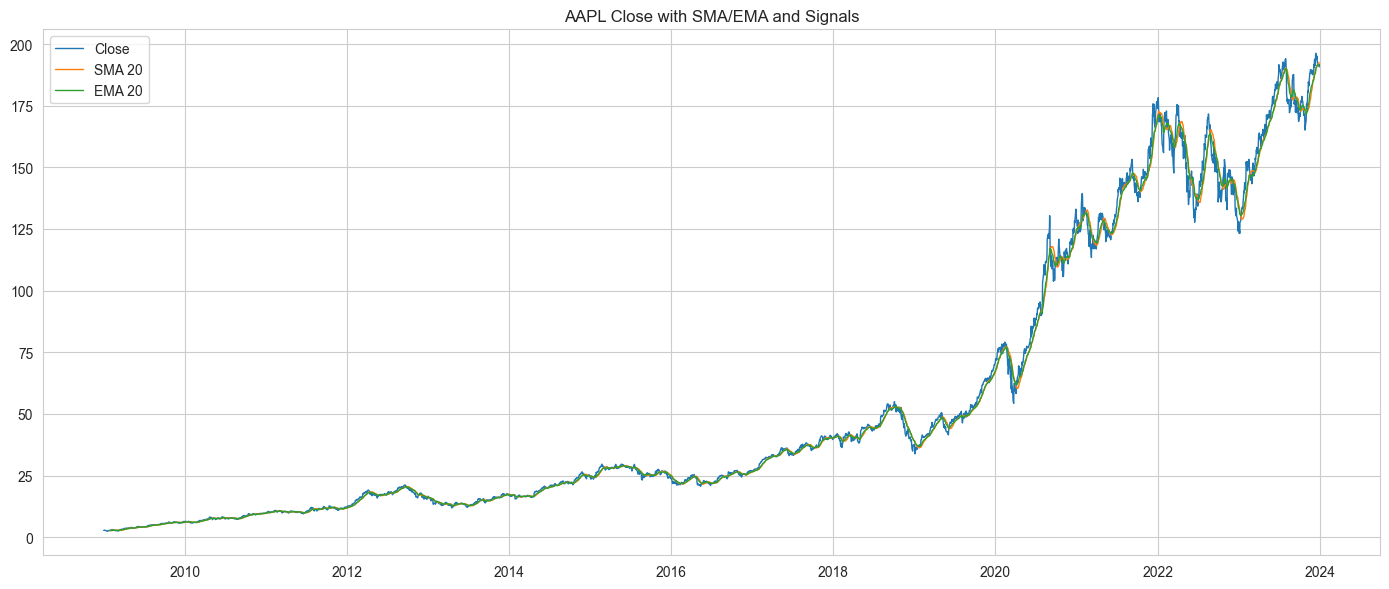

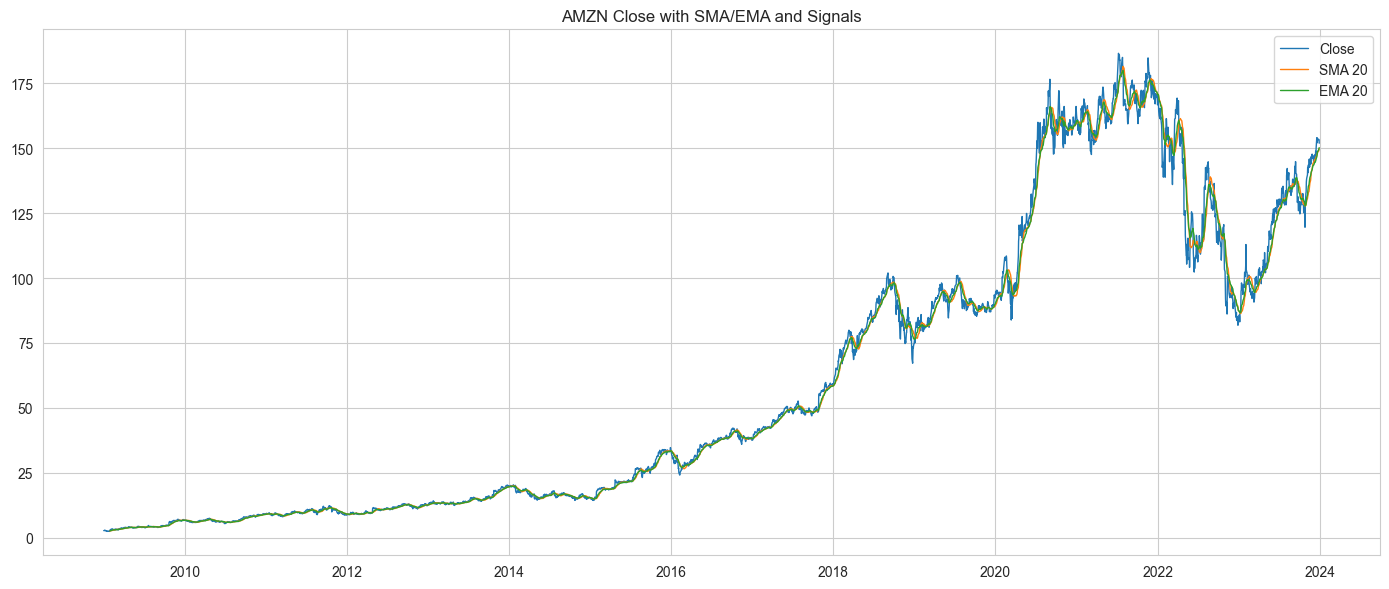

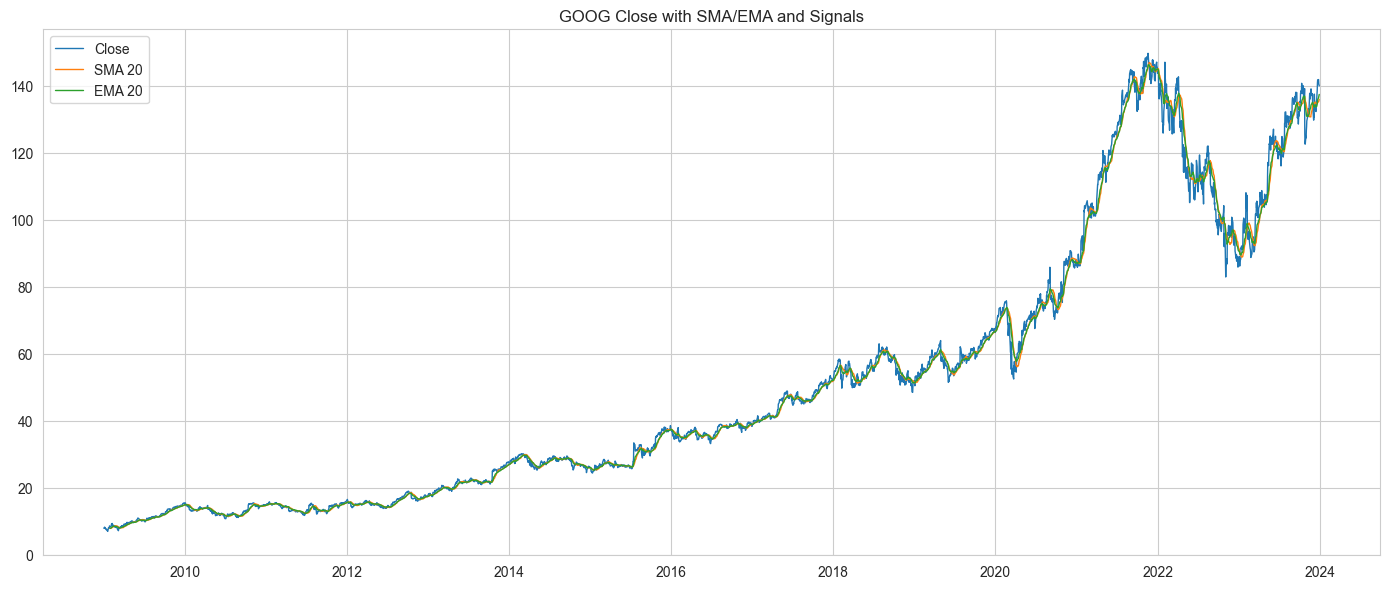

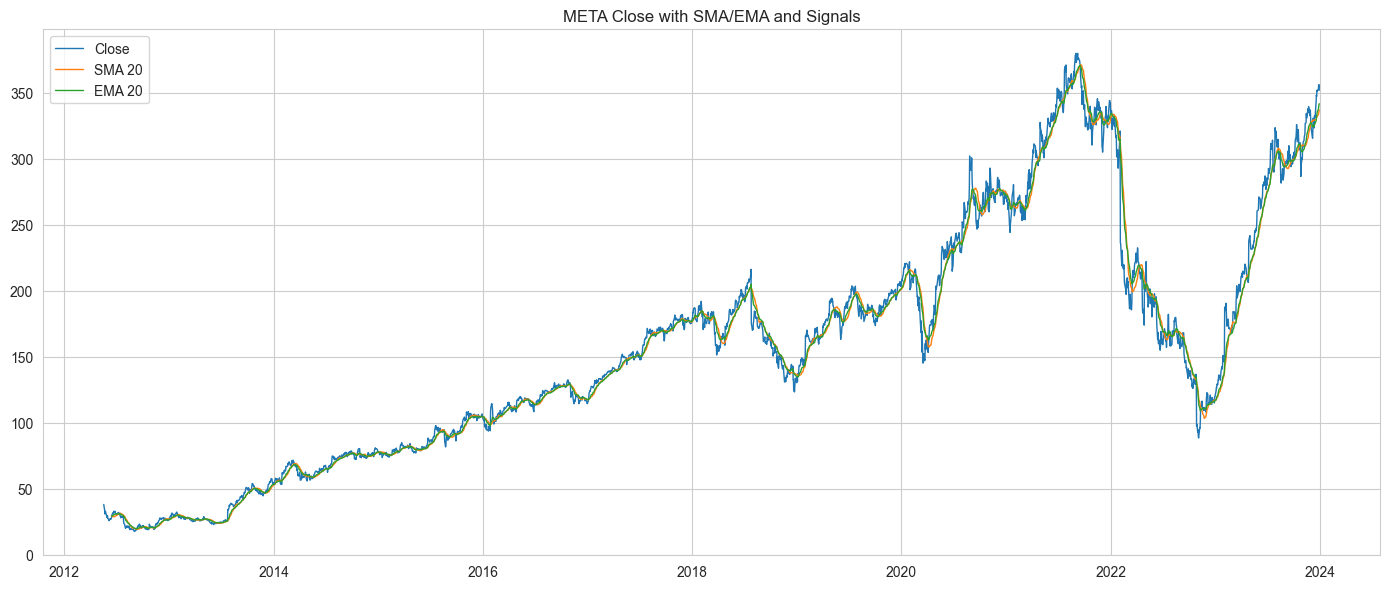

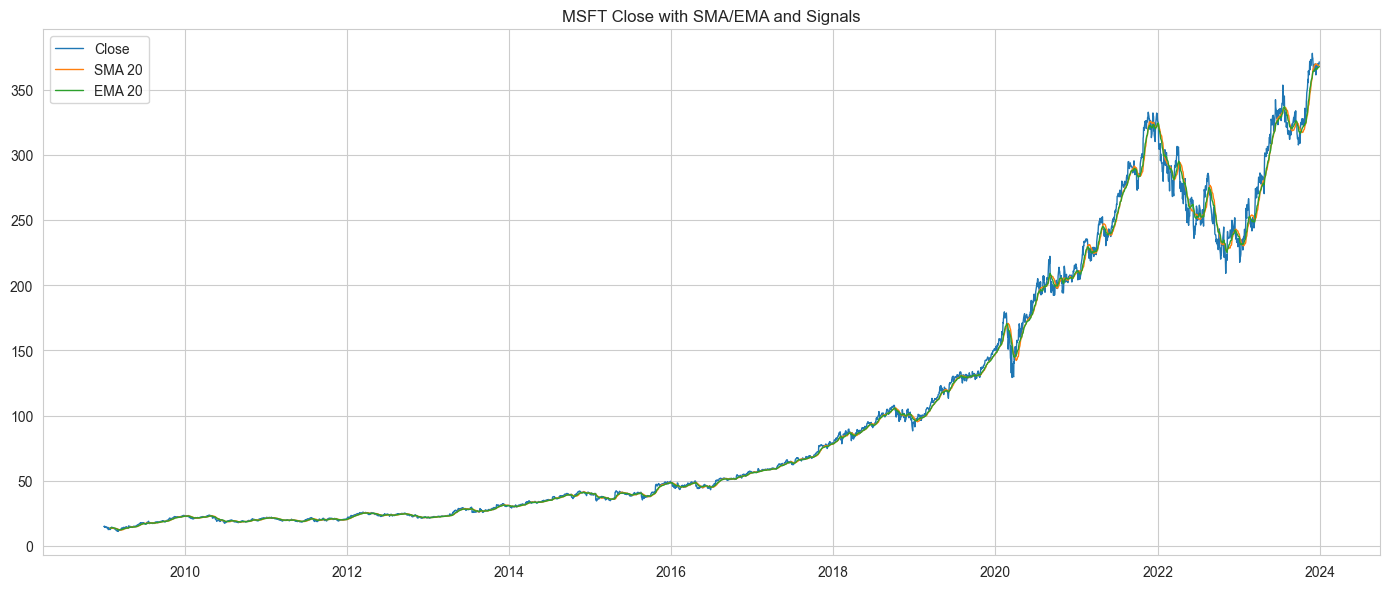

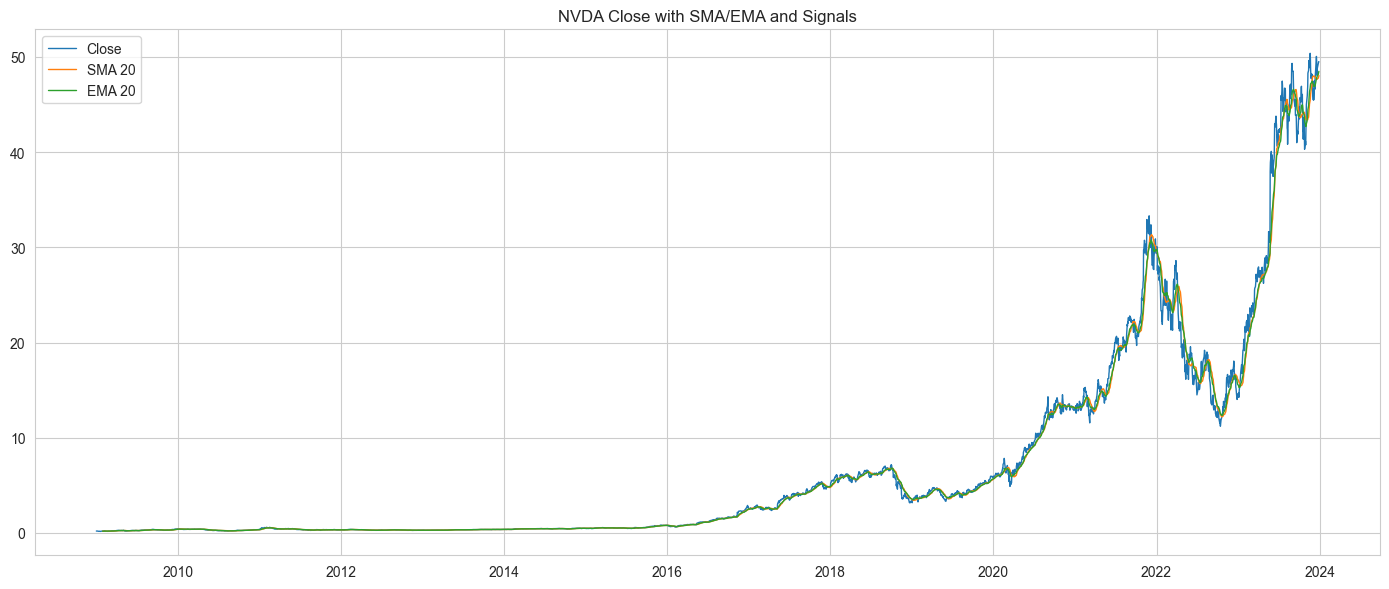

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

def plot_price_with_indicators(stock_name, df):
    plt.figure(figsize=(14,6))
    plt.plot(df.index, df['close'], label='Close', linewidth=1)
    
    # SMA/EMA overlays
    if 'sma_20' in df.columns:
        plt.plot(df.index, df['sma_20'], label='SMA 20', linewidth=1)
    if 'ema_20' in df.columns:
        plt.plot(df.index, df['ema_20'], label='EMA 20', linewidth=1)

    # Optional buy/sell markers from SMA signals
    if 'sig_sma' in df.columns:
        buys = df[df['sig_sma'] == 1]
        sells = df[df['sig_sma'] == -1]
        plt.scatter(buys.index, buys['close'], marker='^', color='green', label='Buy Signal', alpha=0.7)
        plt.scatter(sells.index, sells['close'], marker='v', color='red', label='Sell Signal', alpha=0.7)

    plt.legend()
    plt.title(f"{stock_name} Close with SMA/EMA and Signals")
    plt.tight_layout()
    plt.show()

# Loop over all tickers in stock_data
for ticker, df in stock_data.items():
    plot_price_with_indicators(ticker, df)
